<a href="https://colab.research.google.com/github/toska05/facerec/blob/main/Kopia_notatnika_Demo_BS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python numpy


In [ ]:
!pip install facenet-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.3 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.1.0
    Uninstalling triton-3.1.0:
      Successfully uninstalled triton-3.1.0
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.1.0
    Uninstalling pillow-11.1.0:
      Successfully uninstalled pillow-11.1.0
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.21.5
    Uninstalling nvidia-nccl-cu12-2.21.5:
  

**Mount the drive**

In [ ]:
#Code to mount the Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Extract the files**

In [ ]:
#Code to load the embeddings
import zipfile
zip_path = '/content/actualTestDemo.zip'
extract_path = '/content/actualTestDemo'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"File unzipped at: {extract_path}")


File unzipped at: /content/actualTestDemo


**Generate embeddings from demo images**

In [ ]:
import os
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch

# Initialize models
mtcnn = MTCNN(keep_all=True, post_process=False)  # Disable post-processing to get raw face tensors
resnet = InceptionResnetV1(pretrained='vggface2').eval()

# Configuration
root_test_path = '/content/actualTestDemo'
output_root = '/content/test_embeddings'
os.makedirs(output_root, exist_ok=True)

def process_person_folder(person_path, output_dir):
    # Create output folder for this person
    person_name = os.path.basename(person_path)
    person_output_dir = os.path.join(output_dir, person_name)
    os.makedirs(person_output_dir, exist_ok=True)

    # Process all images for this person
    for img_file in os.listdir(person_path):
        img_path = os.path.join(person_path, img_file)
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')

                # Detect faces
                faces, _ = mtcnn(img, return_prob=True)

                if faces is not None:
                    # Create output subfolder for this image
                    base_name = os.path.splitext(img_file)[0]
                    image_output_dir = os.path.join(person_output_dir, base_name)
                    os.makedirs(image_output_dir, exist_ok=True)

                    embeddings = []
                    # Process each detected face
                    for i, face in enumerate(faces):
                        # Convert face tensor to proper image format
                        face_array = face.numpy().transpose(1, 2, 0)  # Convert from CxHxW to HxWxC
                        face_array = (face_array * 255).astype(np.uint8)  # Scale to 0-255

                        # Save face image
                        face_img = Image.fromarray(face_array)
                        face_img.save(os.path.join(image_output_dir, f'face_{i}.jpg'))

                        # Generate embedding (with proper preprocessing)
                        face_tensor = face.unsqueeze(0).float()  # Add batch dimension
                        face_tensor = (face_tensor - 127.5) / 128.0  # Normalize for ResNet
                        embedding = resnet(face_tensor).detach().numpy().flatten()
                        embeddings.append(embedding)

                    # Save embeddings for this image
                    if embeddings:
                        np.save(os.path.join(image_output_dir, 'embeddings.npy'), np.array(embeddings))

            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")

# Process all person folders in the root test directory
for person_folder in os.listdir(root_test_path):
    person_path = os.path.join(root_test_path, person_folder)
    if os.path.isdir(person_path):
        print(f"Processing person: {person_folder}")
        process_person_folder(person_path, output_root)

print("Face detection and embedding generation completed.")

Processing person: Person 1
Processing person: Natalie Portman
Processing person: Person 2
Processing person: Angelina Jolie
Processing person: Person 3
Face detection and embedding generation completed.


**Compare to gallery for identification**

Loading database embeddings...

Processing test cases...


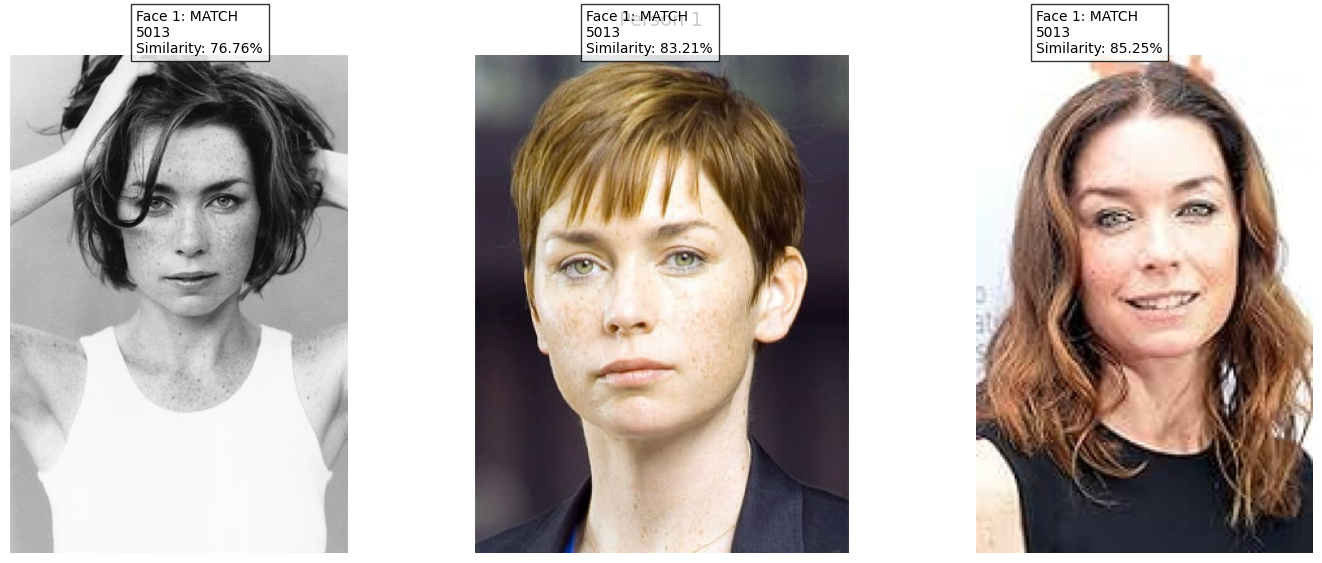

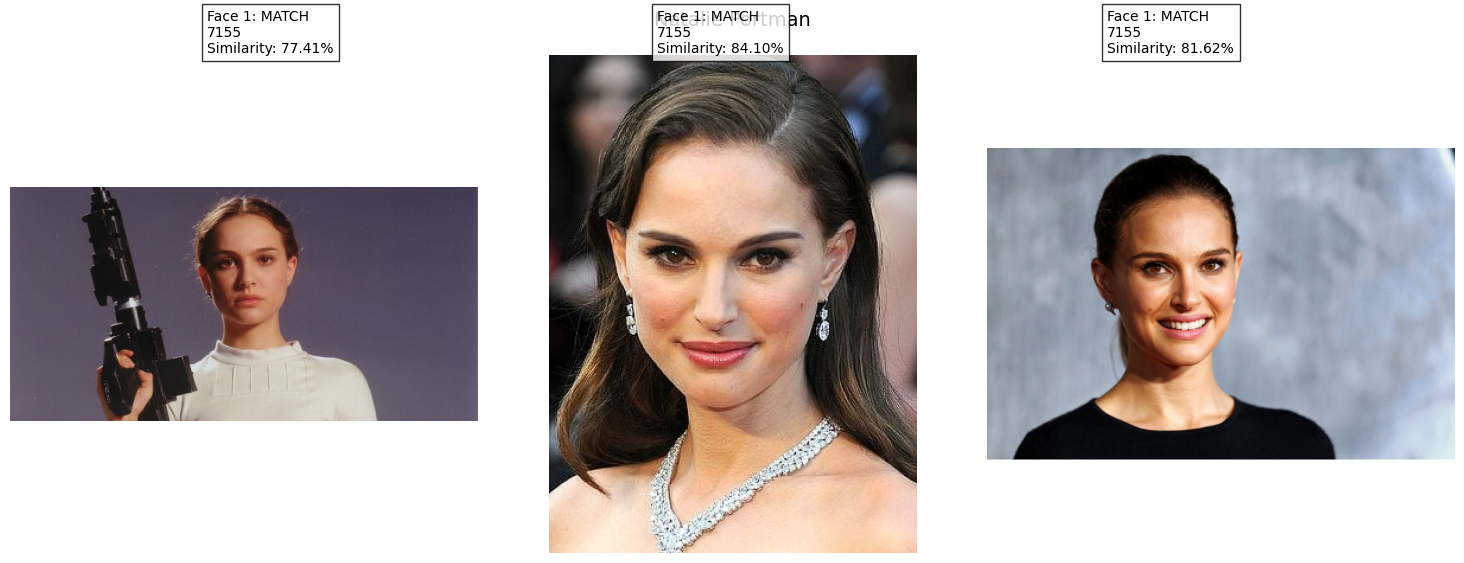

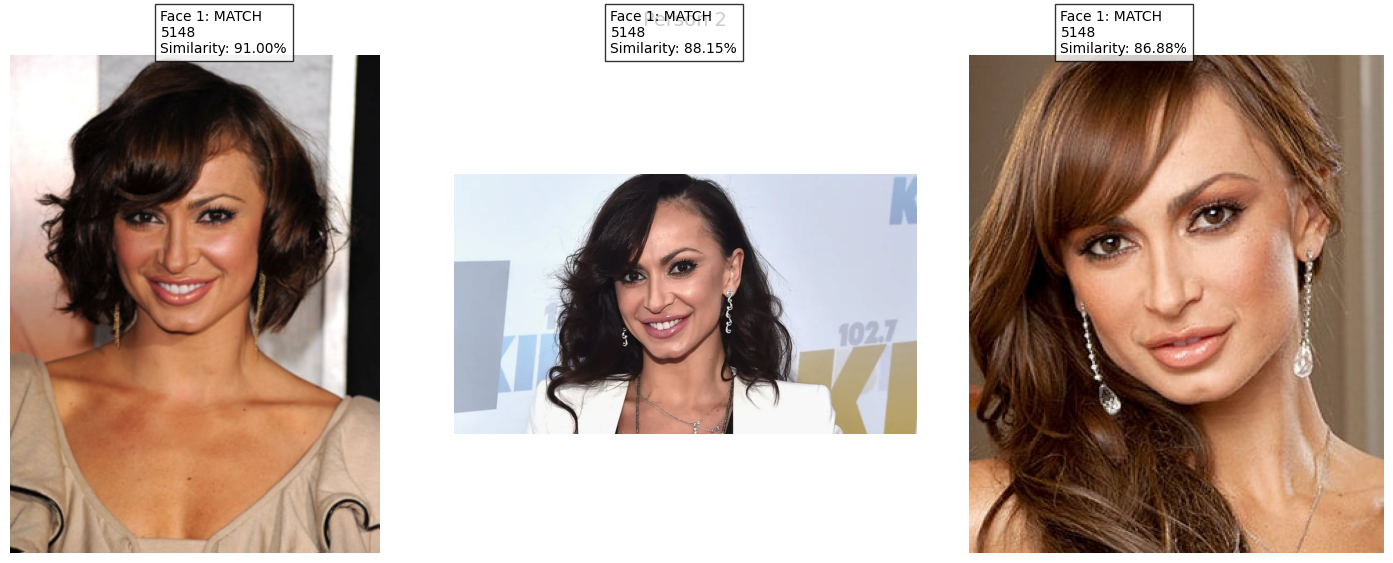

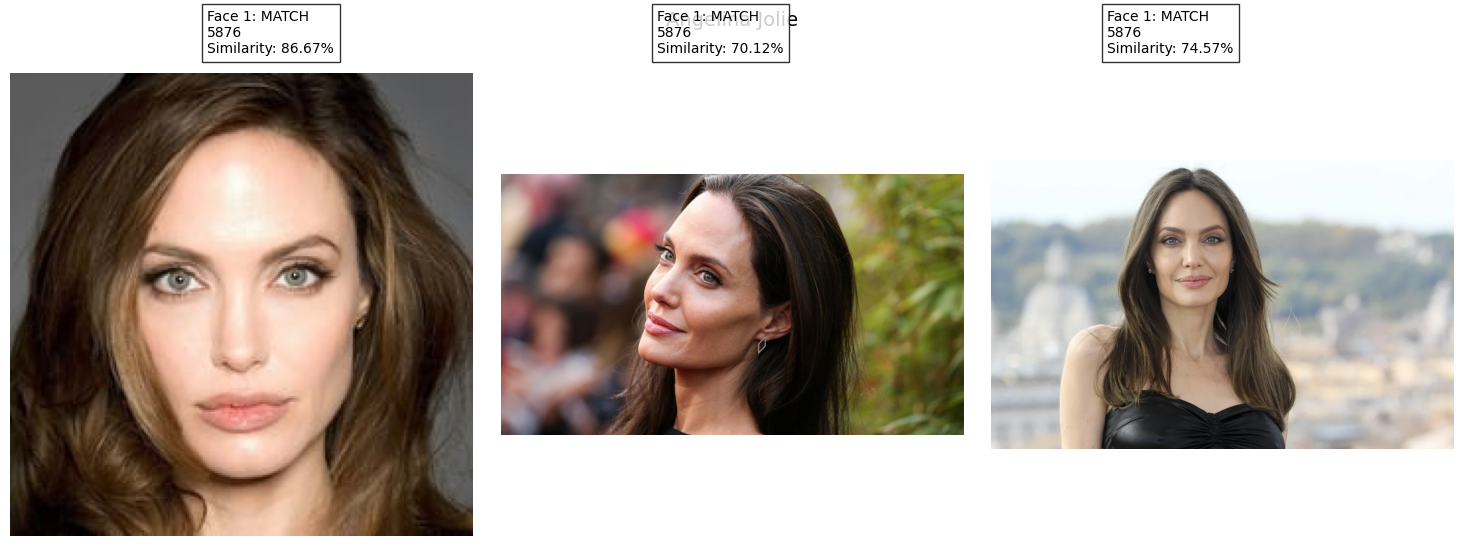

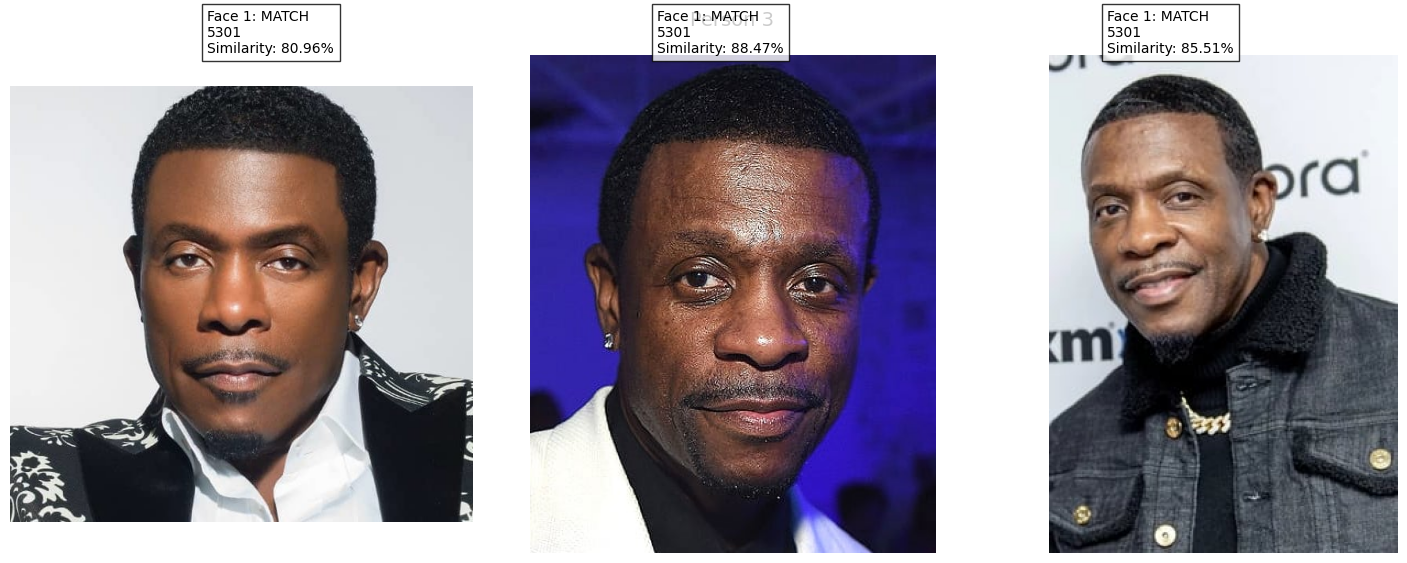


All comparisons completed!


In [ ]:
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from PIL import Image
import matplotlib.pyplot as plt

# Configuration
database_root = '/content/embeddings'
test_embeddings_root = '/content/test_embeddings'
actual_test_root = '/content/actualTestDemo'
threshold = 0.77

# Load database embeddings
print("Loading database embeddings...")
database_embeddings = []
database_labels = []

for db_person in os.listdir(database_root):
    db_person_path = os.path.join(database_root, db_person)
    if os.path.isdir(db_person_path):
        emb_file = os.path.join(db_person_path, 'embeddings.npy')
        if os.path.exists(emb_file):
            embs = np.load(emb_file)
            database_embeddings.extend(embs)
            database_labels.extend([db_person] * len(embs))

database_embeddings = np.array(database_embeddings)
database_labels = np.array(database_labels)

# Process test cases
print("\nProcessing test cases...")
person_results = {}

# Collect results by person
for test_person in os.listdir(test_embeddings_root):
    test_person_path = os.path.join(test_embeddings_root, test_person)
    if not os.path.isdir(test_person_path):
        continue

    person_results[test_person] = []

    for test_image in os.listdir(test_person_path):
        test_case_path = os.path.join(test_person_path, test_image)
        if not os.path.isdir(test_case_path):
            continue

        try:
            # Load embeddings
            embeddings = np.load(os.path.join(test_case_path, 'embeddings.npy'))

            # Load original image
            original_img_path = os.path.join(
                actual_test_root,
                test_person,
                f"{test_image}.jpg"
            )
            if not os.path.exists(original_img_path):
                continue

            original_img = Image.open(original_img_path)

            # Generate results text
            result_text = []
            for idx, embedding in enumerate(embeddings):
                distances = cosine_distances([embedding], database_embeddings)[0]
                best_idx = np.argmin(distances)
                best_dist = distances[best_idx]
                best_label = database_labels[best_idx]

                status = "MATCH" if best_dist <= threshold else "NO MATCH"
                result_text.append(
                    f"Face {idx+1}: {status}\n{best_label}\nSimilarity: {1 - best_dist:.2%}"
                )

            person_results[test_person].append((
                original_img,
                "\n\n".join(result_text)
            ))

        except Exception as e:
            print(f"Error processing {test_case_path}: {str(e)}")

# Display grouped results
for person, images in person_results.items():
    num_images = len(images)
    rows = (num_images + 2) // 3  # 3 images per row

    # Create figure with adjusted spacing
    fig = plt.figure(figsize=(15, 5 * rows + 1))  # +1 inch for header space
    fig.suptitle(person, fontsize=14, y=0.95)  # Lowered y position
    fig.subplots_adjust(top=0.85)  # Add more space at the top

    for idx, (img, text) in enumerate(images, 1):
        ax = plt.subplot(rows, 3, idx)
        ax.imshow(img)
        ax.axis('off')

        # Add text below image with increased offset
        plt.gcf().text(0.15 + 0.3 * ((idx-1) % 3),
                      0.88 - 0.85 * ((idx-1) // 3)/rows,  # Lower y position
                      text,
                      fontsize=10,
                      bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout(pad=2.0)  # Add padding between subplots
    plt.show()

print("\nAll comparisons completed!")

**Remove the test embeddings**

In [ ]:
import shutil, os

def clear_embeddings(folder='/content/test_embeddings'):
    if os.path.exists(folder):
        for item in os.listdir(folder):
            path = os.path.join(folder, item)
            try:
                shutil.rmtree(path) if os.path.isdir(path) else os.remove(path)
            except Exception as e:
                print(f"Error deleting {path}: {e}")
        print("Cleared folder")
    else:
        os.makedirs(folder, exist_ok=True)

clear_embeddings()

Cleared folder
